In [5]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns

In [6]:
data = pd.read_csv("final_defesas_2006a2024.csv")

In [3]:
data["orientador_genero"].value_counts()

orientador_genero
Masculino    935
Feminino      92
sem orcid      1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='ano'>

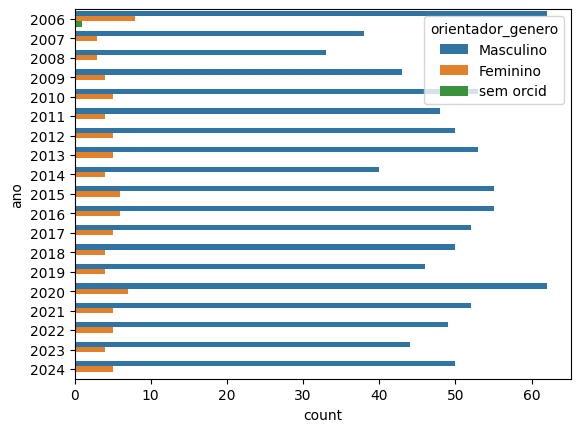

In [3]:
sns.countplot(data=data, y="ano", hue="orientador_genero")

## Criação de nós

In [7]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [185]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        if url.split("/")[-1] == "0000-0002-3823-8941" and data.at[index, f"{col}_genero"] == "Feminino":
            print(index)
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=data.at[index, f"{col}_filiação"],
                            genero=data.at[index, f"{col}_genero"],
                            )
    n_banca -=- 1

97
215
66
188
906
815


In [48]:
# Exemplo de nó:
grafo_defesas.nodes["0000-0002-8803-0401"]

{'nome': 'Rodolfo Azevedo', 'filiacao': 'UNICAMP', 'genero': 'Masculino'}

In [184]:
# Exemplo de nó:
grafo_defesas.nodes["0000-0002-3823-8941"]

{'nome': 'Luiz Eduardo Buzato',
 'filiacao': 'University of Campinas',
 'genero': 'Feminino'}

## Criação de arestas (arestas representam colaborações em defesas de mestrado, mestrado profissional ou doutorado)

In [9]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1, ano=row[1]["ano"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

## Cálculos dos graus máximo e mínimo

In [10]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

max_degree = 0
for no, degree in grafo_defesas.degree():
    if degree > max_degree:
        max_degree = degree
max_degree_person = [no for no, degree in grafo_defesas.degree() if degree == max_degree]

In [9]:
print(f"Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)")
for person in max_degree_person_out:
    print(grafo_defesas.nodes[person], f"Qtd de orientações: {grafo_defesas.out_degree[person]}")

Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)
{'nome': 'Ricardo Torres', 'filiacao': 'Universidade Estadual de Campinas', 'genero': 'Masculino'} Qtd de orientações: 125


In [10]:
print(f"Pessoa(s) com maior quantidade de avaliações (maior grau de ENTRADA)")
for person in max_degree_person_in:
    print(grafo_defesas.nodes[person], f"Qtd de avaliações: {grafo_defesas.in_degree[person]}")

Pessoa(s) com maior quantidade de avaliações (maior grau de ENTRADA)
{'nome': 'Helio Pedrini', 'filiacao': 'University of Campinas', 'genero': 'Masculino'} Qtd de avaliações: 69


In [11]:
print(f"Pessoa(s) com maior quantidade de colaborações (maior grau)")
for person in max_degree_person:
    print(grafo_defesas.nodes[person], f"Qtd de avaliações: {grafo_defesas.degree[person]}")

Pessoa(s) com maior quantidade de colaborações (maior grau)
{'nome': 'Helio Pedrini', 'filiacao': 'University of Campinas', 'genero': 'Masculino'} Qtd de avaliações: 190


### Gráfico log-log com graus de saída (orientação->avaliação)

In [12]:
degree_sequence = [d for _, d in grafo_defesas.out_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

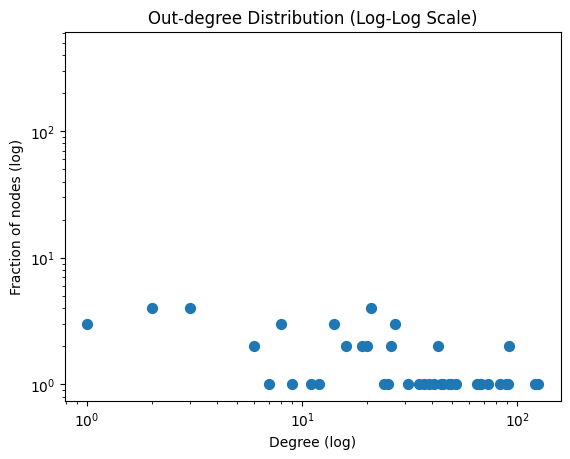

In [13]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Out-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

#### Separando por gênero

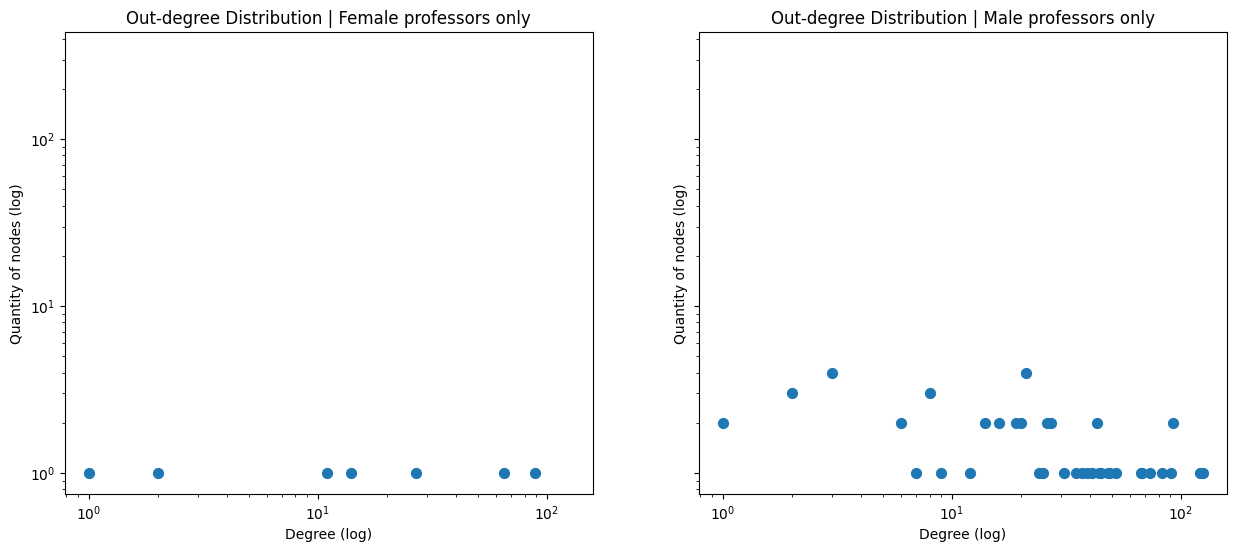

In [67]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True, sharey=True)

genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.out_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[0].scatter(deg, cnt, s=50, color="#1f78b4")

genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.out_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[1].scatter(deg, cnt, s=50, color="#1f78b4")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("Degree (log)")
ax[0].set_ylabel("Quantity of nodes (log)")
ax[0].set_title("Out-degree Distribution | Female professors only")
ax[1].set_xlabel("Degree (log)")
ax[1].set_ylabel("Quantity of nodes (log)")
ax[1].set_title("Out-degree Distribution | Male professors only")



plt.show()

### Gráfico log-log com graus de entrada (avaliação<-orientação)

In [35]:
degree_sequence = [d for _, d in grafo_defesas.in_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

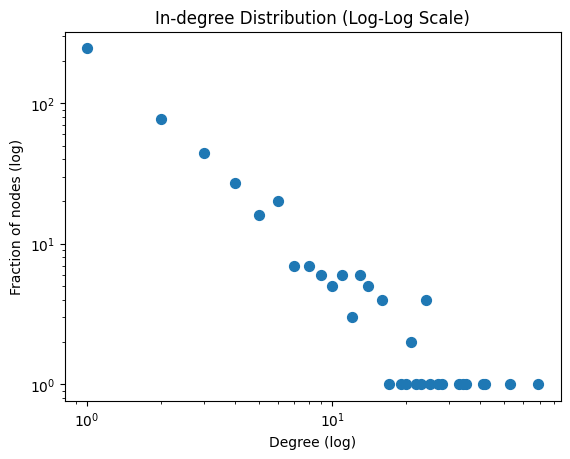

In [38]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

#### Separando por gênero

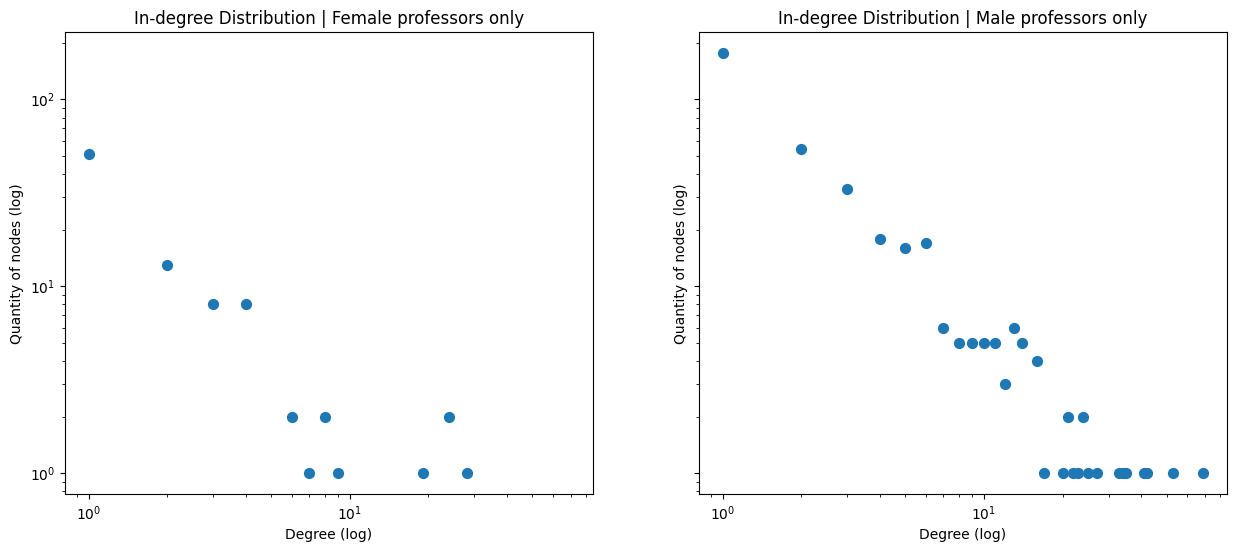

In [68]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True, sharey=True)

genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.in_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[0].scatter(deg, cnt, s=50, color="#1f78b4")

genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
degree_sequence = [d for person, d in grafo_defesas.in_degree() if person in grafo_defesas_genero]  # list of degrees
degree_count = collections.Counter(degree_sequence)
for deg, cnt in sorted(degree_count.items()):
    ax[1].scatter(deg, cnt, s=50, color="#1f78b4")

ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel("Degree (log)")
ax[0].set_ylabel("Quantity of nodes (log)")
ax[0].set_title("In-degree Distribution | Female professors only")
ax[1].set_xlabel("Degree (log)")
ax[1].set_ylabel("Quantity of nodes (log)")
ax[1].set_title("In-degree Distribution | Male professors only")



plt.show()

## Matriz de correlação de graus

In [112]:
deg_corr_matrix = np.zeros(shape=(max_degree, max_degree))

for current_node in grafo_defesas.nodes:
    grau_current_node = grafo_defesas.degree[current_node]
    for adj_node in grafo_defesas[current_node]:
        grau_adj_node = grafo_defesas.degree[adj_node]
        deg_corr_matrix[grau_current_node-1, grau_adj_node-1] -=- 1
        deg_corr_matrix[grau_adj_node-1, grau_current_node-1] -=- 1
deg_corr_matrix /= len(grafo_defesas.edges)

<Axes: >

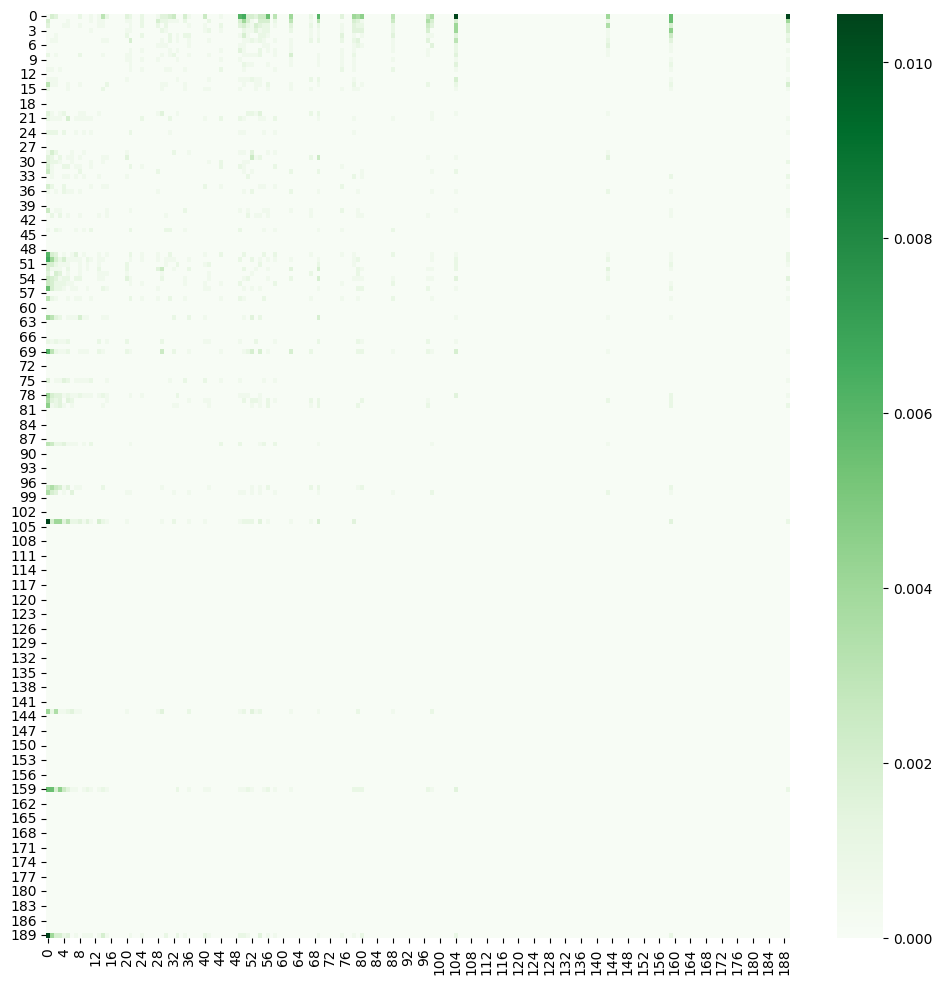

In [113]:
fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(deg_corr_matrix, cmap="Greens")

<Axes: >

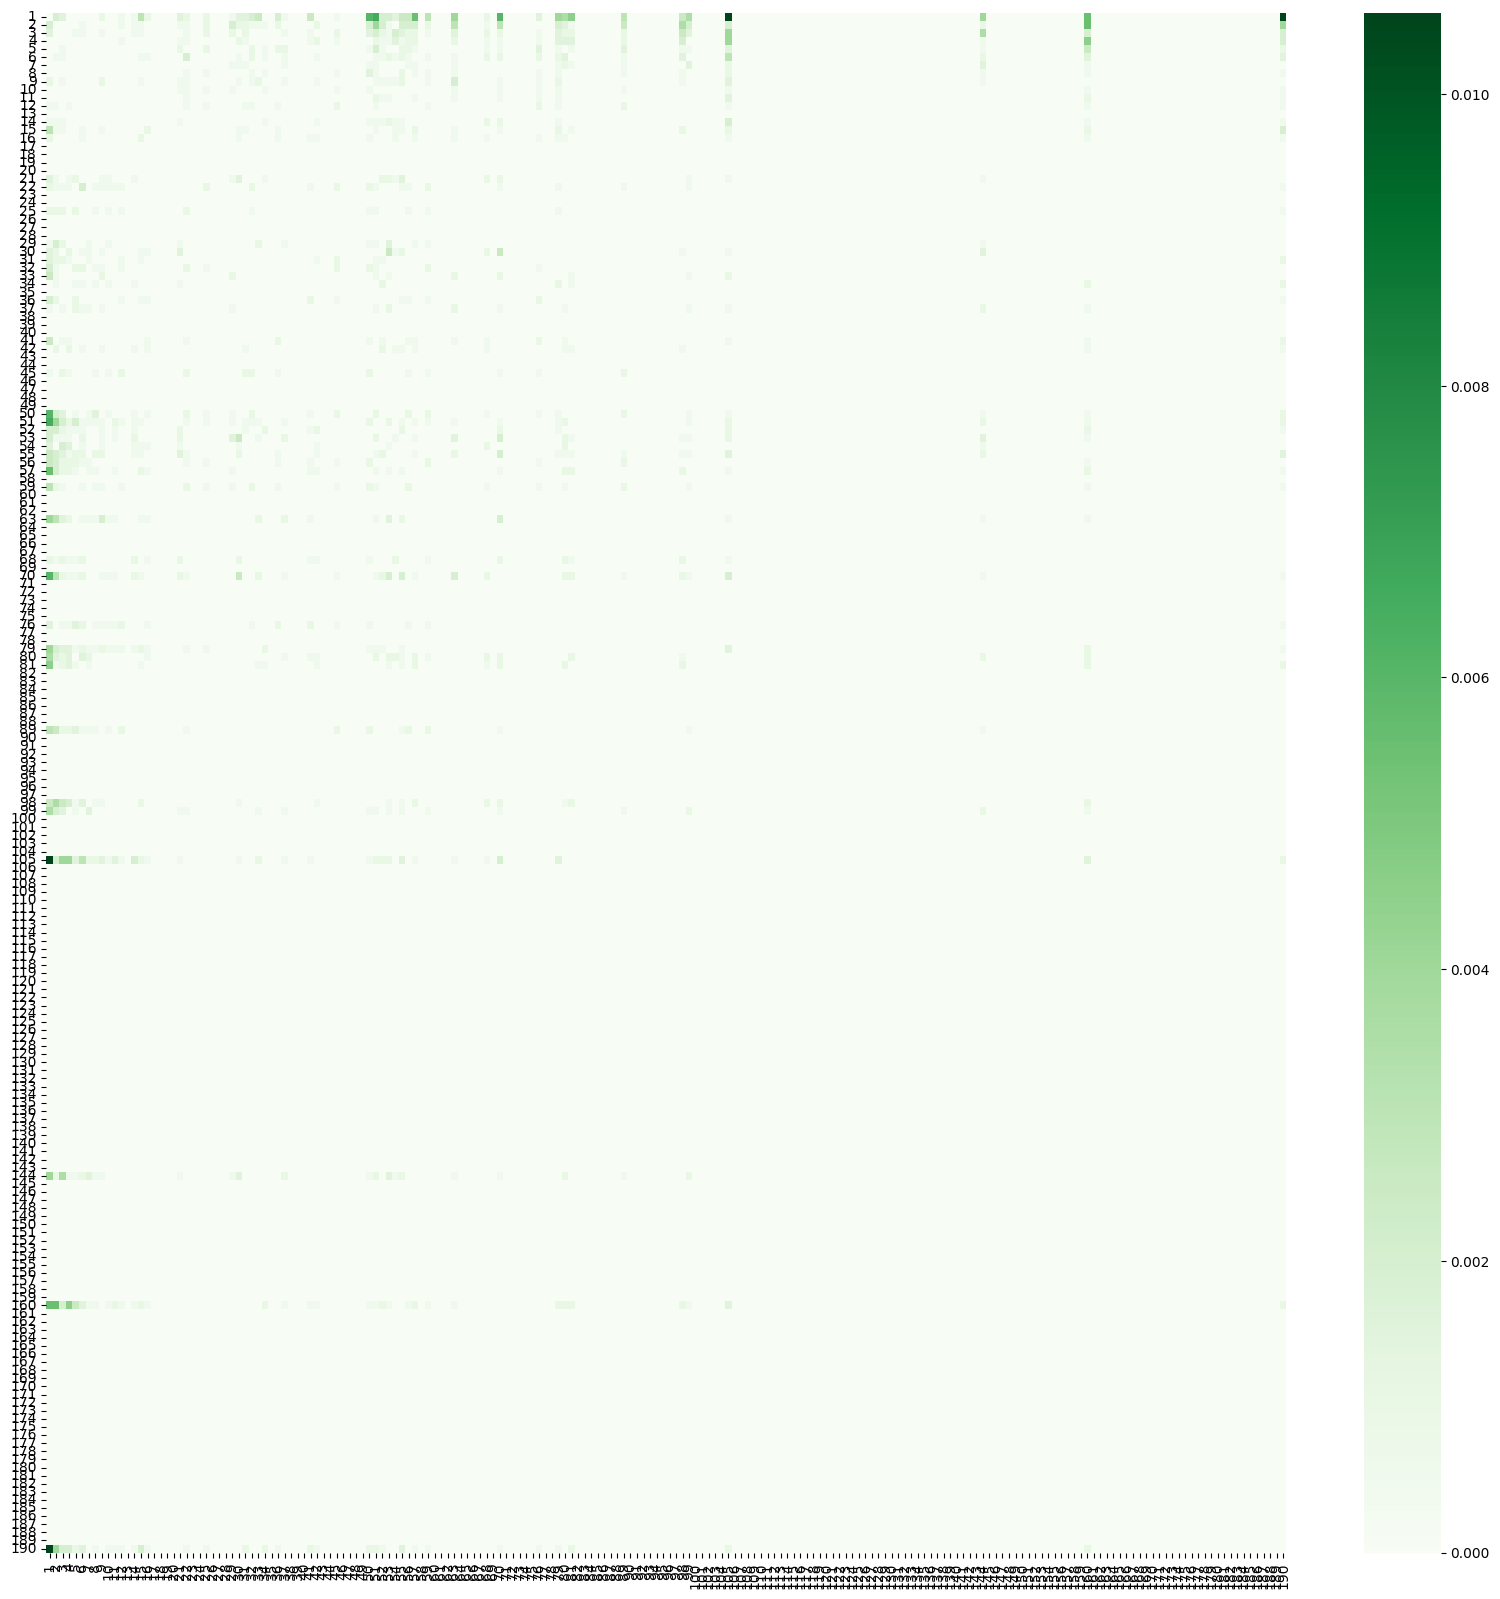

In [107]:
fig, ax = plt.subplots(figsize=(20,20))

sns.heatmap(deg_corr_matrix, cmap="Greens", xticklabels=range(1, 191), yticklabels=range(1, 191))

## Contagem de nós e links

In [34]:
print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas.nodes)}")

Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): 514


In [35]:
print(f"Quantidade de links (cada link representa uma colaboração entre professores em uma banca): {len(grafo_defesas.edges)}")

Quantidade de links (cada link representa uma colaboração entre professores em uma banca): 1989


## Grau médio

In [57]:
print(f"Grau médio dos nós: {np.array([d for _, d in grafo_defesas.degree()]).mean()} \u00B1 {np.array([d for _, d in grafo_defesas.degree()]).std()}")
print(f"Grau médio de saída: {np.array([d for _, d in grafo_defesas.out_degree()]).mean()} \u00B1 {np.array([d for _, d in grafo_defesas.out_degree()]).std()}")
print(f"Grau médio de entrada: {np.array([d for _, d in grafo_defesas.in_degree()]).mean()} \u00B1 {np.array([d for _, d in grafo_defesas.in_degree()]).std()}")

Grau médio dos nós: 7.739299610894942 ± 20.006860017466067
Grau médio de saída: 3.869649805447471 ± 14.821917369480712
Grau médio de entrada: 3.869649805447471 ± 6.635341431191931


### Por gênero

In [55]:
genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
graus = np.array([d for pessoa, d in grafo_defesas.degree() if pessoa in grafo_defesas_genero])
graus_saida = np.array([d for pessoa, d in grafo_defesas.out_degree() if pessoa in grafo_defesas_genero])
graus_entrada = np.array([d for pessoa, d in grafo_defesas.in_degree() if pessoa in grafo_defesas_genero])
print(f"{genero}:")
print(f"Grau médio dos nós: {graus.mean()} \u00B1 {graus.std()}")
print(f"Grau médio de saída: {graus_saida.mean()} \u00B1 {graus_saida.std()}")
print(f"Grau médio de entrada: {graus_entrada.mean()} \u00B1 {graus_entrada.std()}")

Feminino:
Grau médio dos nós: 5.117021276595745 ± 14.906700180661817
Grau médio de saída: 2.223404255319149 ± 11.638302734449955
Grau médio de entrada: 2.893617021276596 ± 4.774640646178078


In [56]:
genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]
graus = np.array([d for pessoa, d in grafo_defesas.degree() if pessoa in grafo_defesas_genero])
graus_saida = np.array([d for pessoa, d in grafo_defesas.out_degree() if pessoa in grafo_defesas_genero])
graus_entrada = np.array([d for pessoa, d in grafo_defesas.in_degree() if pessoa in grafo_defesas_genero])
print(f"{genero}:")
print(f"Grau médio dos nós: {graus.mean()} \u00B1 {graus.std()}")
print(f"Grau médio de saída: {graus_saida.mean()} \u00B1 {graus_saida.std()}")
print(f"Grau médio de entrada: {graus_entrada.mean()} \u00B1 {graus_entrada.std()}")

Masculino:
Grau médio dos nós: 8.9296875 ± 21.788585359900654
Grau médio de saída: 4.635416666666667 ± 16.07023632868298
Grau médio de entrada: 4.294270833333333 ± 7.22728975319582


## Colaborações

In [169]:
adj_matrix = nx.adjacency_matrix(grafo_defesas)
colabs = pd.DataFrame(data=adj_matrix,
             columns=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())],
                    index=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())])

In [115]:
colabs.head()

,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"
Rodolfo Azevedo,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Luiz Velho,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Célio Albuquerque,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Neucimar Leite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Luiz Eduardo Buzato,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [160]:
nodes_unicamp_orcid = []

for edge in grafo_defesas.out_edges:
    nodes_unicamp_orcid.append(edge[0])
nodes_unicamp_orcid = set(nodes_unicamp_orcid)

In [161]:
nodes_unicamp = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if node in nodes_unicamp_orcid]

In [162]:
len(nodes_unicamp)

63

In [170]:
colabs.loc[nodes_unicamp, nodes_unicamp].values.max()

np.int64(26)

<Axes: >

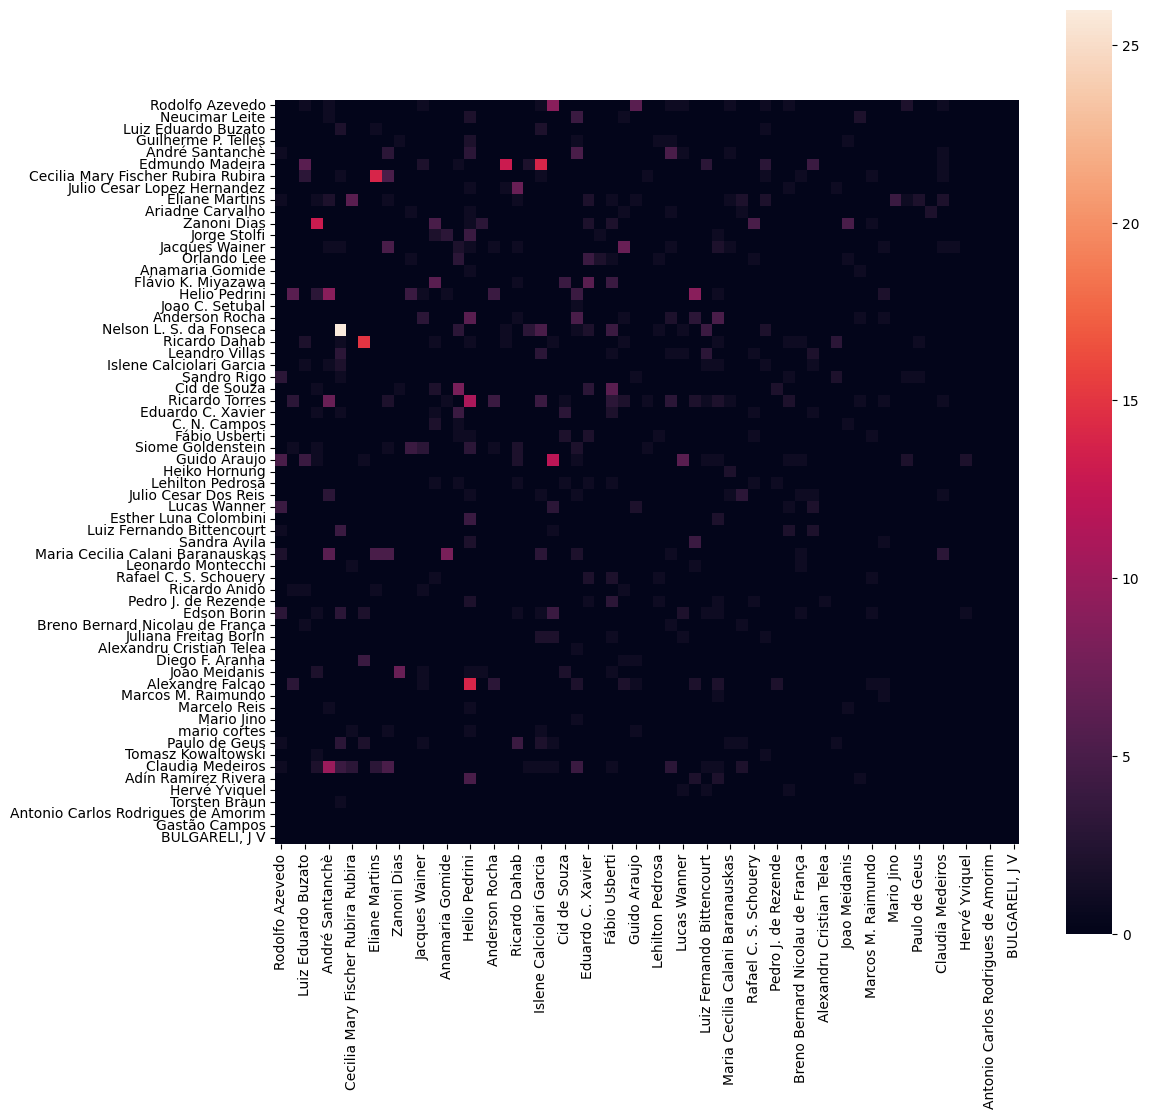

In [173]:
fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(colabs.loc[nodes_unicamp, nodes_unicamp], square=True)

In [181]:
nodes_unicamp_fem = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and 
                                                                                           grafo_defesas.nodes[node]["genero"] == "Feminino")]
nodes_unicamp_masc = [grafo_defesas.nodes[node]["nome"] for node in grafo_defesas.nodes if (node in nodes_unicamp_orcid and 
                                                                                           grafo_defesas.nodes[node]["genero"] == "Masculino")]

In [183]:
grafo_defesas.nodes["0000-0002-3823-8941"]

{'nome': 'Luiz Eduardo Buzato',
 'filiacao': 'University of Campinas',
 'genero': 'Feminino'}

In [182]:
nodes_unicamp_fem

['Luiz Eduardo Buzato',
 'Ariadne Carvalho',
 'Flávio K. Miyazawa',
 'Sandra Avila',
 'Maria Cecilia Calani Baranauskas',
 'Alexandru Cristian Telea',
 'BULGARELI, J V']

In [179]:
colabs.loc[nodes_unicamp_fem, nodes_unicamp_fem]

,Luiz Eduardo Buzato,Ariadne Carvalho,Flávio K. Miyazawa,Sandra Avila,Maria Cecilia Calani Baranauskas,Alexandru Cristian Telea,"BULGARELI, J V"
Luiz Eduardo Buzato,0,0,0,0,0,0,0
Ariadne Carvalho,0,0,0,0,0,0,0
Flávio K. Miyazawa,0,0,0,0,0,0,0
Sandra Avila,0,0,0,0,0,0,0
Maria Cecilia Calani Baranauskas,0,5,0,0,0,0,0
Alexandru Cristian Telea,0,0,0,0,0,0,0
"BULGARELI, J V",0,0,0,0,0,0,0


In [107]:
colabs_dict = nx.to_dict_of_dicts(grafo_defesas)
conta_colabs = []
dupla_colabs = []
for pessoa1, colabs in colabs_dict.items():
    for pessoa2 in colabs_dict[pessoa1]:
        conta_colabs.append(len(colabs_dict[pessoa1][pessoa2]))
        dupla_colabs.append((pessoa1, pessoa2))

In [140]:
top_n = 10
for i in range(1, top_n+1):
    # i==
    idx_colab = np.argsort(conta_colabs)[-i]
    # print(idx_colab)
    pessoa1 = grafo_defesas.nodes[dupla_colabs[idx_colab][0]]["nome"]
    pessoa2 = grafo_defesas.nodes[dupla_colabs[idx_colab][1]]["nome"]
    qtd = conta_colabs[idx_colab]
    print(f"Colaboração entre {pessoa1} e {pessoa2} com {qtd}")

Colaboração entre Nelson L. S. da Fonseca e Edmundo Madeira com 26
Colaboração entre Ricardo Dahab e Julio Cesar Lopez Hernandez com 15
Colaboração entre Alexandre Falcao e Helio Pedrini com 14
Colaboração entre Cecilia Mary Fischer Rubira Rubira e Eliane Martins com 14
Colaboração entre Edmundo Madeira e Islene Calciolari Garcia com 14
Colaboração entre Zanoni Dias e Guilherme P. Telles com 13
Colaboração entre Edmundo Madeira e Nelson L. S. da Fonseca com 13
Colaboração entre Guido Araujo e Sandro Rigo com 12
Colaboração entre Ricardo Torres e Helio Pedrini com 11
Colaboração entre Zanoni Dias e Maria Emilia Walter com 11


In [111]:
len(colabs_dict["0000-0002-1180-2637"]["0000-0003-2046-602X"])

13

In [141]:
len(colabs_dict["0000-0003-0125-630X"]["0000-0002-8253-9004"])

1

In [113]:
len(colabs_dict["0000-0001-9068-938X"]["0000-0003-0125-630X"])

2

In [103]:
pessoa

'0000-0002-8803-0401'

In [98]:
nx.to_dict_of_lists(grafo_defesas)

{'0000-0002-8803-0401': ['0000-0002-9539-6874',
  '0000-0002-8856-194X',
  '0000-0003-1561-8447',
  '0000-0002-1163-9980',
  '0000-0002-3891-1593',
  '0000-0003-4869-5190',
  '0000-0002-9384-8347',
  '0000-0002-5178-3661',
  '0000-0002-9957-5861',
  '0000-0003-1399-7535',
  '0000-0003-1908-4753',
  '0000-0002-0375-1657',
  '0000-0003-3738-6448',
  '0000-0002-1756-4852',
  '0000-0002-4830-5298',
  '0000-0002-6560-6965',
  '0000-0003-3233-0314',
  '0000-0001-8824-3055',
  '0000-0002-5564-698X',
  '0000-0002-3823-8941',
  '0000-0003-1783-4231',
  '0000-0002-6023-5982',
  '0000-0003-2419-6979',
  '0000-0003-4268-9726',
  '0000-0003-1840-2895',
  '0000-0003-2970-2084',
  '0000-0001-5201-1244',
  '0000-0002-9545-2098'],
 '0000-0001-5489-4909': [],
 '0000-0002-7959-6569': [],
 '0000-0001-5015-2131': ['0000-0001-8522-2056',
  '0000-0002-2914-5380',
  '0000-0003-4929-7258',
  '0000-0001-5685-8004',
  '0000-0002-9554-1381',
  '0000-0001-9772-263X',
  '0000-0003-4861-7061',
  '0000-0003-3861-7260

In [79]:
colabs_list = nx.to_dict_of_lists(grafo_defesas)

In [80]:
for pessoa, colabs in colabs_list.items():
    break

In [83]:
colabs_list["0000-0002-1180-2637"]

['0000-0002-3823-8941',
 '0000-0001-5746-4154',
 '0000-0002-8856-194X',
 '0000-0003-2046-602X',
 '0000-0001-5378-4732',
 '0000-0002-6023-5982',
 '0000-0001-9892-740X',
 '0000-0002-7561-5582',
 '0000-0003-3888-7340',
 '0000-0003-1908-4753',
 '0000-0001-5201-1244',
 '0000-0002-7789-3359',
 '0000-0003-2715-6796',
 '0000-0003-2162-6523',
 '0000-0002-5455-8910',
 '0000-0001-6305-9059',
 '0000-0002-5591-3750',
 '0000-0002-7959-6569',
 '0000-0001-8956-8660',
 '0000-0002-8603-699X',
 '0000-0002-5660-6488',
 '0000-0002-5861-4414',
 '0000-0002-5250-1785',
 '0000-0003-3109-4305',
 '0000-0003-4861-7061',
 '0000-0002-1067-6421',
 '0000-0002-3087-9234',
 '0000-0002-3372-3366',
 '0000-0003-1119-2450',
 '0000-0002-2312-7042',
 '0000-0002-8781-3914',
 '0000-0002-1095-6714',
 '0000-0002-4034-0021',
 '0000-0002-8111-1719',
 '0000-0002-2407-0981']

In [87]:
len(collections.Counter(colabs_list["0000-0003-2046-602X"]))

30

In [89]:
len(set(collections.Counter(colabs_list["0000-0003-2046-602X"])))

30

In [86]:
set(collections.Counter(colabs_list["0000-0003-2046-602X"]))

{'0000-0001-6030-2682',
 '0000-0001-6305-9059',
 '0000-0001-8515-0582',
 '0000-0001-8585-706X',
 '0000-0001-9756-378X',
 '0000-0001-9772-263X',
 '0000-0002-1067-6421',
 '0000-0002-1180-2637',
 '0000-0002-3372-3366',
 '0000-0002-4851-5228',
 '0000-0002-4865-5896',
 '0000-0002-4961-3428',
 '0000-0002-5193-8643',
 '0000-0002-5227-9221',
 '0000-0002-5564-698X',
 '0000-0002-5591-3750',
 '0000-0002-6023-5982',
 '0000-0002-6275-6503',
 '0000-0002-6972-6913',
 '0000-0002-7561-5582',
 '0000-0002-7789-3359',
 '0000-0002-7959-6569',
 '0000-0002-8856-194X',
 '0000-0002-8972-080X',
 '0000-0002-9936-3770',
 '0000-0003-1001-082X',
 '0000-0003-2046-602X',
 '0000-0003-2223-947X',
 '0000-0003-2823-4725',
 '0000-0003-3109-4305'}

In [ ]:
# links_por_ano = collections.defaultdict(int)
# for edge in grafo_defesas.edges:
#     colabs.at[grafo_defesas.nodes[edge[0]]["nome"], grafo_defesas.nodes[edge[1]]["nome"]] -=- 1
#     # colabs.at[grafo_defesas.nodes[edge[1]]["nome"], grafo_defesas.nodes[edge[0]]["nome"]] -=- 1

In [ ]:
links_por_ano = collections.defaultdict(int)
for edge in grafo_defesas.out_edges:
    colabs.at[grafo_defesas.nodes[edge[0]]["nome"], grafo_defesas.nodes[edge[1]]["nome"]] -=- 1
    # colabs.at[grafo_defesas.nodes[edge[1]]["nome"], grafo_defesas.nodes[edge[0]]["nome"]] -=- 1

In [37]:
grafo_defesas.edges

OutMultiEdgeView([('0000-0002-8803-0401', '0000-0002-9539-6874', 0), ('0000-0002-8803-0401', '0000-0002-9539-6874', 1), ('0000-0002-8803-0401', '0000-0002-9539-6874', 2), ('0000-0002-8803-0401', '0000-0002-9539-6874', 3), ('0000-0002-8803-0401', '0000-0002-9539-6874', 4), ('0000-0002-8803-0401', '0000-0002-9539-6874', 5), ('0000-0002-8803-0401', '0000-0002-9539-6874', 6), ('0000-0002-8803-0401', '0000-0002-9539-6874', 7), ('0000-0002-8803-0401', '0000-0002-9539-6874', 8), ('0000-0002-8803-0401', '0000-0002-8856-194X', 0), ('0000-0002-8803-0401', '0000-0003-1561-8447', 0), ('0000-0002-8803-0401', '0000-0002-1163-9980', 0), ('0000-0002-8803-0401', '0000-0002-3891-1593', 0), ('0000-0002-8803-0401', '0000-0002-3891-1593', 1), ('0000-0002-8803-0401', '0000-0003-4869-5190', 0), ('0000-0002-8803-0401', '0000-0003-4869-5190', 1), ('0000-0002-8803-0401', '0000-0003-4869-5190', 2), ('0000-0002-8803-0401', '0000-0003-4869-5190', 3), ('0000-0002-8803-0401', '0000-0003-4869-5190', 4), ('0000-0002-8

In [72]:
colabs.describe()

,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"
count,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,...,514.000000,514.000000,514.000000,514.000000,514.000000,514.0,514.0,514.0,514.0,514.0
mean,0.042802,0.001946,0.005837,0.027237,0.036965,0.005837,0.011673,0.005837,0.003891,0.005837,...,0.001946,0.001946,0.001946,0.001946,0.001946,0.0,0.0,0.0,0.0,0.0
std,0.361550,0.044108,0.098552,0.329270,0.364875,0.098552,0.186952,0.132324,0.088216,0.132324,...,0.044108,0.044108,0.044108,0.044108,0.044108,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
max,5.000000,1.000000,2.000000,6.000000,6.000000,2.000000,4.000000,3.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0


In [73]:
colabs

,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"
Rodolfo Azevedo,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Luiz Velho,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Célio Albuquerque,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Neucimar Leite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Luiz Eduardo Buzato,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"AMORIM, Raul Reis",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Torsten Braun,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Antonio Carlos Rodrigues de Amorim,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Gastão Campos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
colabs.values.max()

np.int64(26)

In [68]:
a = colabs.where(colabs==colabs.values.max()).dropna(how="all").dropna(axis=1)
a.index, a.columns, colabs.values.max()

(Index(['Nelson L. S. da Fonseca'], dtype='object'),
 Index(['Edmundo Madeira'], dtype='object'),
 np.int64(26))

In [59]:
colabs.where(colabs==1)

,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"
Rodolfo Azevedo,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Luiz Velho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Célio Albuquerque,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Neucimar Leite,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Luiz Eduardo Buzato,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"AMORIM, Raul Reis",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Torsten Braun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Antonio Carlos Rodrigues de Amorim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gastão Campos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
colabs.loc["Rodolfo Azevedo", :].max()

np.int64(9)

In [67]:
a = colabs.where(colabs==9).dropna(how="all").dropna(axis=1)
a.index, a.columns, colabs.values.max()

(Index(['Rodolfo Azevedo', 'Helio Pedrini'], dtype='object'),
 Index([], dtype='object'),
 np.int64(26))

In [40]:
colabs.shape

(514, 514)

<Axes: >

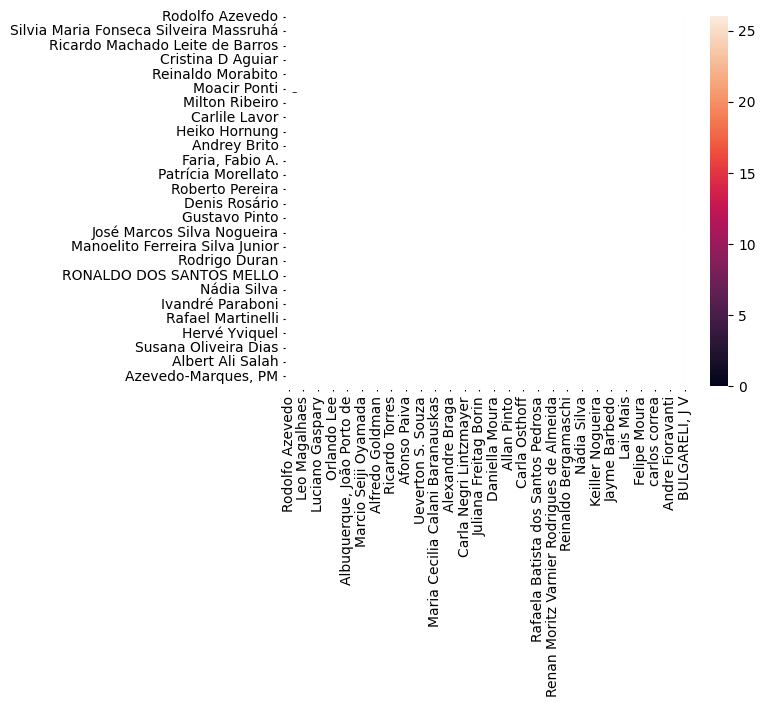

In [41]:
sns.heatmap(colabs, annot=True)

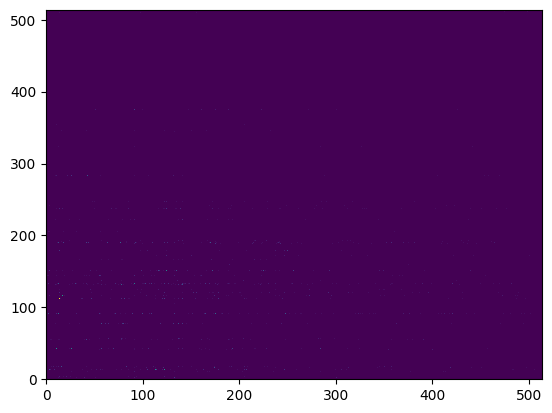

In [42]:
plt.pcolor(colabs)